<div style="background: linear-gradient(135deg, #1a3a5c 0%, #2C7BB6 60%, #1A9641 100%); padding: 40px 32px 32px 32px; border-radius: 10px; margin-bottom: 8px;">
  <h1 style="color: #ffffff; font-size: 2.0em; font-weight: 700; margin: 0 0 10px 0; font-family: Calibri, sans-serif; letter-spacing: 0.5px;">
    Financial Risk Management and Engineering — Session 8: Derivatives in Risk Management
  </h1>
  <p style="color: #d0e8ff; font-size: 1.05em; margin: 0; font-family: Calibri, sans-serif;">
    Aarhus Summer University &nbsp;·&nbsp; July 2026
  </p>
</div>

<div style="background:#f0f4fa; border-left:5px solid #2C7BB6; padding:14px 18px; border-radius:5px; margin-top:10px;">
  <b>Session overview:</b> This notebook builds a complete derivatives pricing and hedging toolkit using real AAPL data. We cover Black–Scholes pricing, the Greeks (Δ, Γ, ν, Θ, ρ), CRR binomial trees, put–call parity, a live delta-hedging simulation, and implied-volatility extraction — the core concepts of the <i>Financial Risk Manager Handbook</i> derivatives curriculum.
</div>

<div style="background:#0D2B45;border-left:6px solid #2E86C1;padding:14px 22px;border-radius:6px;margin:22px 0 8px 0"><span style="font-size:1.2em;font-weight:700;color:#7BC8F6">Setup &mdash; Source Material, Packages &amp; Environment Check</span><br><span style="color:#BDC3C7;font-size:0.93em">Run this first &middot; works on any recent Python 3.9+</span></div>

<div style="background:#0D2B45;border-left:5px solid #2E86C1;padding:13px 20px;border-radius:0 8px 8px 0;margin:10px 0"><span style="color:#7DB5D8;font-weight:bold">&#128218; Source material &nbsp;</span><span style="color:#B8D4E8;line-height:1.7">This session follows <b>Hull (2023), <i>Risk Management and Financial Institutions</i> (6th ed.): Ch. 15 (Derivatives Risk &mdash; Greeks and Hedging)</b>; and <b>Jorion (2010), <i>Financial Risk Manager Handbook</i> (6th ed.): Ch. 8 (Option Markets)</b>.</span></div>

This notebook uses the standard scientific-Python stack. If you installed **[Anaconda](https://www.anaconda.com/download)** most of these are already present; otherwise install everything in one line (from a terminal, or prefix with `!` in a cell):

```
pip install yfinance pandas numpy matplotlib seaborn scipy
```

No installs allowed on your machine? **[Google Colab](https://colab.research.google.com)** runs this notebook free in the browser &mdash; upload the `.ipynb` and add a first cell with `!pip install yfinance pandas numpy matplotlib seaborn scipy`.

<div style="background:#0A2A1A;border-left:5px solid #1E8449;padding:12px 18px;border-radius:0 8px 8px 0;margin:10px 0"><span style="color:#52C97A;font-weight:bold">&#10003; Environment check &nbsp;</span><span style="color:#90D4A8;line-height:1.7">Run the cell below. Every line should print a version number. Anything marked <code>NOT INSTALLED</code> tells you exactly what to <code>pip install</code>, then <b>Kernel &rarr; Restart &amp; Run All</b>.</span></div>

In [1]:
import importlib, sys
print('Python', sys.version.split()[0], '\n')
for pkg in ['numpy', 'pandas', 'matplotlib', 'scipy', 'yfinance', 'seaborn']:
    try:
        m = importlib.import_module(pkg)
        print(f'  {pkg:13s} {getattr(m, "__version__", "ok")}')
    except Exception:
        print(f'  {pkg:13s} NOT INSTALLED  ->  pip install {pkg}')

Python 3.13.3 

  numpy         2.1.3


  pandas        2.2.3
  matplotlib    3.10.0
  scipy         1.17.1


  yfinance      0.2.55


  seaborn       0.13.2


<div style="border-left:5px solid #D4A017;background:#1C1400;padding:8px 14px;border-radius:0 5px 5px 0;margin:4px 0"><b style="color:#F0B429">&#128172;</b> <b>When things break.</b> <b>Run cells top to bottom</b> &mdash; order matters. If results look wrong, <b>Kernel &rarr; Restart &amp; Run All</b>. Common errors: <code>ModuleNotFoundError</code> &rarr; <code>pip install &lt;name&gt;</code> then restart; <code>NameError</code> &rarr; you skipped the cell that defines it; <code>YFRateLimitError</code> &rarr; Yahoo throttled you, wait a minute &mdash; this notebook caches data in <code>notebook_data/</code> so a re-run works offline. Read the <b>last</b> line of a traceback first.</div>

In [2]:
# ── Imports ──────────────────────────────────────────────────────────────────
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.optimize import brentq
from scipy.stats import norm
import yfinance as yf
import os, time
from pandas_datareader import data as pdr

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})

# Colour palette (matches course design language)
NAVY   = '#1a3a5c'
BLUE   = '#2C7BB6'
GREEN  = '#1A9641'
RED    = '#D7191C'
GOLD   = '#FDAE61'
PURPLE = '#762A83'
PALETTE = [BLUE, RED, GREEN, GOLD, PURPLE, '#4DAC26']

# ── Parameters ───────────────────────────────────────────────────────────────
START     = '2021-07-01'
END       = '2026-07-01'

# Risk-free rate from FRED, matched to the option tenor (or closest available tenor)
def get_fred_treasury_yield(series_id, start=None, end=None):
    """Fetch the latest Treasury yield from FRED as a decimal rate."""
    try:
        df = pdr.DataReader(series_id, 'fred', start=start, end=end)
    except Exception as e:
        print(f'FRED lookup failed for {series_id}: {e}')
        return None

    if isinstance(df, pd.Series):
        s = df.dropna()
    elif isinstance(df, pd.DataFrame):
        if series_id in df.columns:
            s = df[series_id].dropna()
        else:
            s = df.iloc[:, 0].dropna()
    else:
        return None

    if s.empty:
        print(f'No FRED data returned for {series_id}')
        return None

    latest = s.iloc[-1]
    return float(latest) / 100.0

# Use the same maturity as the option (default 0.5y / 6M; later cells use T_ex=0.5)
OPTION_TENOR_YEARS = globals().get('T_ex', 0.5)

# Map common option tenors to FRED Treasury series IDs
treasury_map = {
    0.25: 'DGS3MO',
    0.5:  'DGS6MO',
    1.0:  'DGS1',
    2.0:  'DGS2',
    3.0:  'DGS3',
    5.0:  'DGS5',
    7.0:  'DGS7',
    10.0: 'DGS10',
    30.0: 'DGS30',
}

tenors = np.array(list(treasury_map.keys()), dtype=float)
closest_tenor = tenors[np.argmin(np.abs(tenors - OPTION_TENOR_YEARS))]
series_id = treasury_map[float(closest_tenor)]

rf_rate = get_fred_treasury_yield(series_id, start=START, end=END)
RF_ANNUAL = rf_rate if rf_rate is not None else 0.04

TICKER = 'AAPL'

print(f'Using FRED Treasury yield: {series_id} ({closest_tenor:.2f}y) -> {RF_ANNUAL:.2%}')

np.random.seed(42)

print('Libraries loaded ✓')
print(f'Underlying: {TICKER} | Period: {START} → {END} | rf = {RF_ANNUAL:.0%}')

Using FRED Treasury yield: DGS6MO (0.50y) -> 4.00%
Libraries loaded ✓
Underlying: AAPL | Period: 2021-07-01 → 2026-07-01 | rf = 4%


In [3]:
# ── Download & cache AAPL data ────────────────────────────────────────────────
CACHE_DIR  = 'notebook_data'
CACHE_FILE = os.path.join(CACHE_DIR, 'Session_08_data.csv')

os.makedirs(CACHE_DIR, exist_ok=True)

def download_with_retry(ticker, start, end, retries=3):
    for attempt in range(1, retries + 1):
        try:
            raw = yf.download(ticker, start=start, end=end,
                              auto_adjust=True, progress=False)
            if raw is not None and len(raw) > 10:
                return raw
        except Exception as e:
            print(f'Attempt {attempt} failed: {e}')
            time.sleep(2)
    return None

if os.path.exists(CACHE_FILE):
    _raw = pd.read_csv(CACHE_FILE, header=[0, 1], index_col=0, parse_dates=True)
    prices = _raw['Close']
    print(f'Loaded from cache: {len(prices)} rows')
else:
    raw = download_with_retry(TICKER, START, END)
    if raw is not None:
        raw.to_csv(CACHE_FILE)
        prices = raw['Close']
        print(f'Downloaded {len(prices)} rows → cached to {CACHE_FILE}')
    else:
        raise RuntimeError('Data download failed after 3 retries.')

# Ensure `prices` is a 1-D Series regardless of yfinance column layout
if isinstance(prices, pd.DataFrame):
    prices = prices.iloc[:, 0]
prices.name = TICKER

# Log returns and realised volatility
log_returns  = np.log(prices / prices.shift(1)).dropna()
realised_vol = log_returns.std() * np.sqrt(252)  # annualised

S0    = float(prices.iloc[-1])   # current price (last available)
sigma = float(realised_vol)      # realised vol from full sample

print(f'\nPrice on {prices.index[-1].date()}: ${S0:.2f}')
print(f'Realised annual volatility: {sigma:.1%}')
print(f'Sample: {prices.index[0].date()} → {prices.index[-1].date()}, {len(prices)} trading days')

Loaded from cache: 1254 rows

Price on 2026-06-30: $289.36
Realised annual volatility: 27.6%
Sample: 2021-07-01 → 2026-06-30, 1254 trading days


---
## Part 1 — Black–Scholes Pricing Framework

<div style="background:#eaf4fb; border-left:5px solid #2C7BB6; padding:14px 18px; border-radius:5px;">
  <b>Theory:</b> Under the Black–Scholes model, a European call/put on a non-dividend-paying stock has closed-form prices driven by <b>d₁</b> and <b>d₂</b>:

$$d_1 = \frac{\ln(S/K) + (r + \tfrac{1}{2}\sigma^2)T}{\sigma\sqrt{T}}, \qquad d_2 = d_1 - \sigma\sqrt{T}$$

$$C = S\,N(d_1) - K e^{-rT}N(d_2), \qquad P = K e^{-rT}N(-d_2) - S\,N(-d_1)$$

</div>

In [4]:
# ── Black–Scholes functions (adapted from black_scholes.py helper) ─────────────

def bs_d1(S, K, T, r, sigma):
    """d1 component of the Black–Scholes formula."""
    return (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))

def bs_d2(S, K, T, r, sigma):
    """d2 = d1 - sigma*sqrt(T)."""
    return bs_d1(S, K, T, r, sigma) - sigma * np.sqrt(T)

def bs_call(S, K, T, r, sigma):
    """Black–Scholes European call price."""
    d1, d2 = bs_d1(S, K, T, r, sigma), bs_d2(S, K, T, r, sigma)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def bs_put(S, K, T, r, sigma):
    """Black–Scholes European put price."""
    d1, d2 = bs_d1(S, K, T, r, sigma), bs_d2(S, K, T, r, sigma)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

# ── Example: ATM option on AAPL ──────────────────────────────────────────────
K_atm = round(S0 / 5) * 5    # nearest $5 strike
T_ex  = 0.5                   # 6-month expiry
r     = RF_ANNUAL

call_price = bs_call(S0, K_atm, T_ex, r, sigma)
put_price  = bs_put (S0, K_atm, T_ex, r, sigma)

d1_val = bs_d1(S0, K_atm, T_ex, r, sigma)
d2_val = bs_d2(S0, K_atm, T_ex, r, sigma)

print('=== Black–Scholes ATM Option Prices ===')
print(f'  Underlying (S₀):   ${S0:>8.2f}')
print(f'  Strike (K):        ${K_atm:>8.2f}')
print(f'  Expiry (T):        {T_ex:.1f} years')
print(f'  Risk-free rate (r):{r:.2%}')
print(f'  Volatility (σ):    {sigma:.1%}')
print(f'  d₁ = {d1_val:.4f},  d₂ = {d2_val:.4f}')
print(f'  Call price: ${call_price:.4f}')
print(f'  Put  price: ${put_price:.4f}')

=== Black–Scholes ATM Option Prices ===
  Underlying (S₀):   $  289.36
  Strike (K):        $  290.00
  Expiry (T):        0.5 years
  Risk-free rate (r):4.00%
  Volatility (σ):    27.6%
  d₁ = 0.1887,  d₂ = -0.0067
  Call price: $24.9685
  Put  price: $19.8661


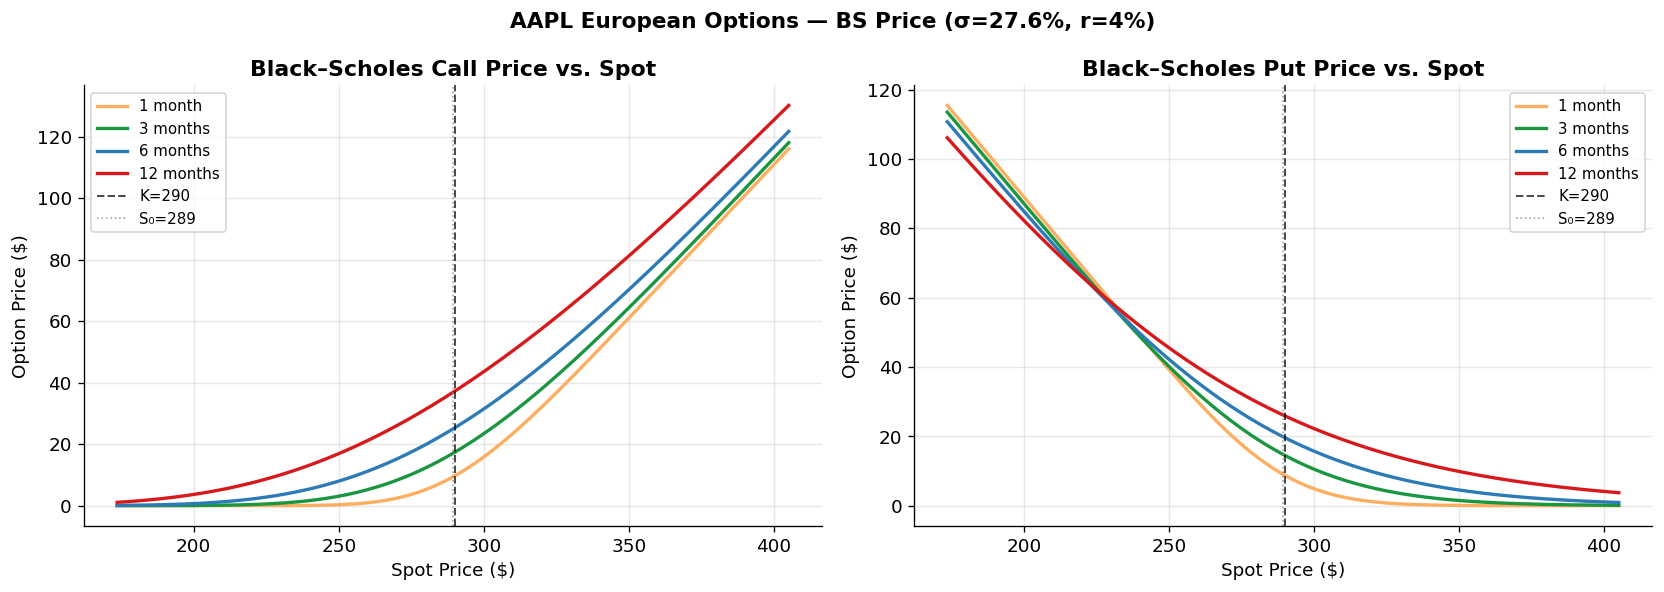

In [5]:
# ── Call and Put price surfaces vs. spot and time ─────────────────────────────
spot_range = np.linspace(S0 * 0.6, S0 * 1.4, 200)
T_vals     = [1/12, 3/12, 6/12, 12/12]  # 1m, 3m, 6m, 12m
T_labels   = ['1 month', '3 months', '6 months', '12 months']
T_colors   = [GOLD, GREEN, BLUE, RED]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for T_val, T_lbl, col in zip(T_vals, T_labels, T_colors):
    calls = bs_call(spot_range, K_atm, T_val, r, sigma)
    puts  = bs_put (spot_range, K_atm, T_val, r, sigma)
    axes[0].plot(spot_range, calls, color=col, lw=2, label=T_lbl)
    axes[1].plot(spot_range, puts,  color=col, lw=2, label=T_lbl)

for ax, title in zip(axes, ['Call Price', 'Put Price']):
    ax.axvline(K_atm, color='black', lw=1.2, ls='--', alpha=0.7, label=f'K={K_atm}')
    ax.axvline(S0,    color='grey',  lw=1.0, ls=':',  alpha=0.7, label=f'S₀={S0:.0f}')
    ax.set_xlabel('Spot Price ($)')
    ax.set_ylabel('Option Price ($)')
    ax.set_title(f'Black–Scholes {title} vs. Spot', fontweight='bold')
    ax.legend(fontsize=9)

plt.suptitle(f'{TICKER} European Options — BS Price (σ={sigma:.1%}, r={r:.0%})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 2 — The Greeks: Closed-Form Sensitivities

<div style="background:#eafaf1; border-left:5px solid #1A9641; padding:14px 18px; border-radius:5px;">

| Greek | Call | Put | Interpretation |
|-------|------|-----|----------------|
| **Delta** Δ | N(d₁) | N(d₁) − 1 | Change in option value per $1 move in S |
| **Gamma** Γ | N′(d₁) / (Sσ√T) | same | Rate of change of delta |
| **Vega** ν | S·N′(d₁)·√T | same | Sensitivity to 1-pt change in volatility |
| **Theta** Θ | (complex) | (complex) | Daily time-decay |
| **Rho** ρ | K·T·e^{-rT}·N(d₂) | −K·T·e^{-rT}·N(−d₂) | Sensitivity to interest rate |

</div>

In [6]:
# ── Greeks (closed-form) ──────────────────────────────────────────────────────

def bs_delta(S, K, T, r, sigma, option='call'):
    d1 = bs_d1(S, K, T, r, sigma)
    if option == 'call':
        return norm.cdf(d1)
    return norm.cdf(d1) - 1

def bs_gamma(S, K, T, r, sigma):
    d1 = bs_d1(S, K, T, r, sigma)
    return norm.pdf(d1) / (S * sigma * np.sqrt(T))

def bs_vega(S, K, T, r, sigma):
    """Vega: $ change per +1% volatility move (divide by 100 for per-point)."""
    d1 = bs_d1(S, K, T, r, sigma)
    return S * norm.pdf(d1) * np.sqrt(T) / 100  # per 1% vol

def bs_theta(S, K, T, r, sigma, option='call'):
    """Theta: daily time decay (per calendar day)."""
    d1 = bs_d1(S, K, T, r, sigma)
    d2 = bs_d2(S, K, T, r, sigma)
    term1 = -S * norm.pdf(d1) * sigma / (2 * np.sqrt(T))
    if option == 'call':
        return (term1 - r * K * np.exp(-r * T) * norm.cdf(d2)) / 365
    return (term1 + r * K * np.exp(-r * T) * norm.cdf(-d2)) / 365

def bs_rho(S, K, T, r, sigma, option='call'):
    """Rho: $ change per +1% interest rate move."""
    d2 = bs_d2(S, K, T, r, sigma)
    if option == 'call':
        return K * T * np.exp(-r * T) * norm.cdf(d2)  / 100
    return -K * T * np.exp(-r * T) * norm.cdf(-d2) / 100

# ── Report for ATM option ─────────────────────────────────────────────────────
greeks = {
    'Delta':  (bs_delta(S0, K_atm, T_ex, r, sigma, 'call'),
               bs_delta(S0, K_atm, T_ex, r, sigma, 'put')),
    'Gamma':  (bs_gamma(S0, K_atm, T_ex, r, sigma),) * 2,
    'Vega':   (bs_vega (S0, K_atm, T_ex, r, sigma),) * 2,
    'Theta':  (bs_theta(S0, K_atm, T_ex, r, sigma, 'call'),
               bs_theta(S0, K_atm, T_ex, r, sigma, 'put')),
    'Rho':    (bs_rho  (S0, K_atm, T_ex, r, sigma, 'call'),
               bs_rho  (S0, K_atm, T_ex, r, sigma, 'put')),
}

df_greeks = pd.DataFrame(greeks, index=['Call', 'Put']).T
print('=== Greeks for ATM option (S₀, K, T, r, σ) ===')
print(df_greeks.round(6).to_string())

=== Greeks for ATM option (S₀, K, T, r, σ) ===
           Call       Put
Delta  0.574855 -0.425145
Gamma  0.006930  0.006930
Vega   0.801858  0.801858
Theta -0.076209 -0.045057
Rho    0.706858 -0.714430


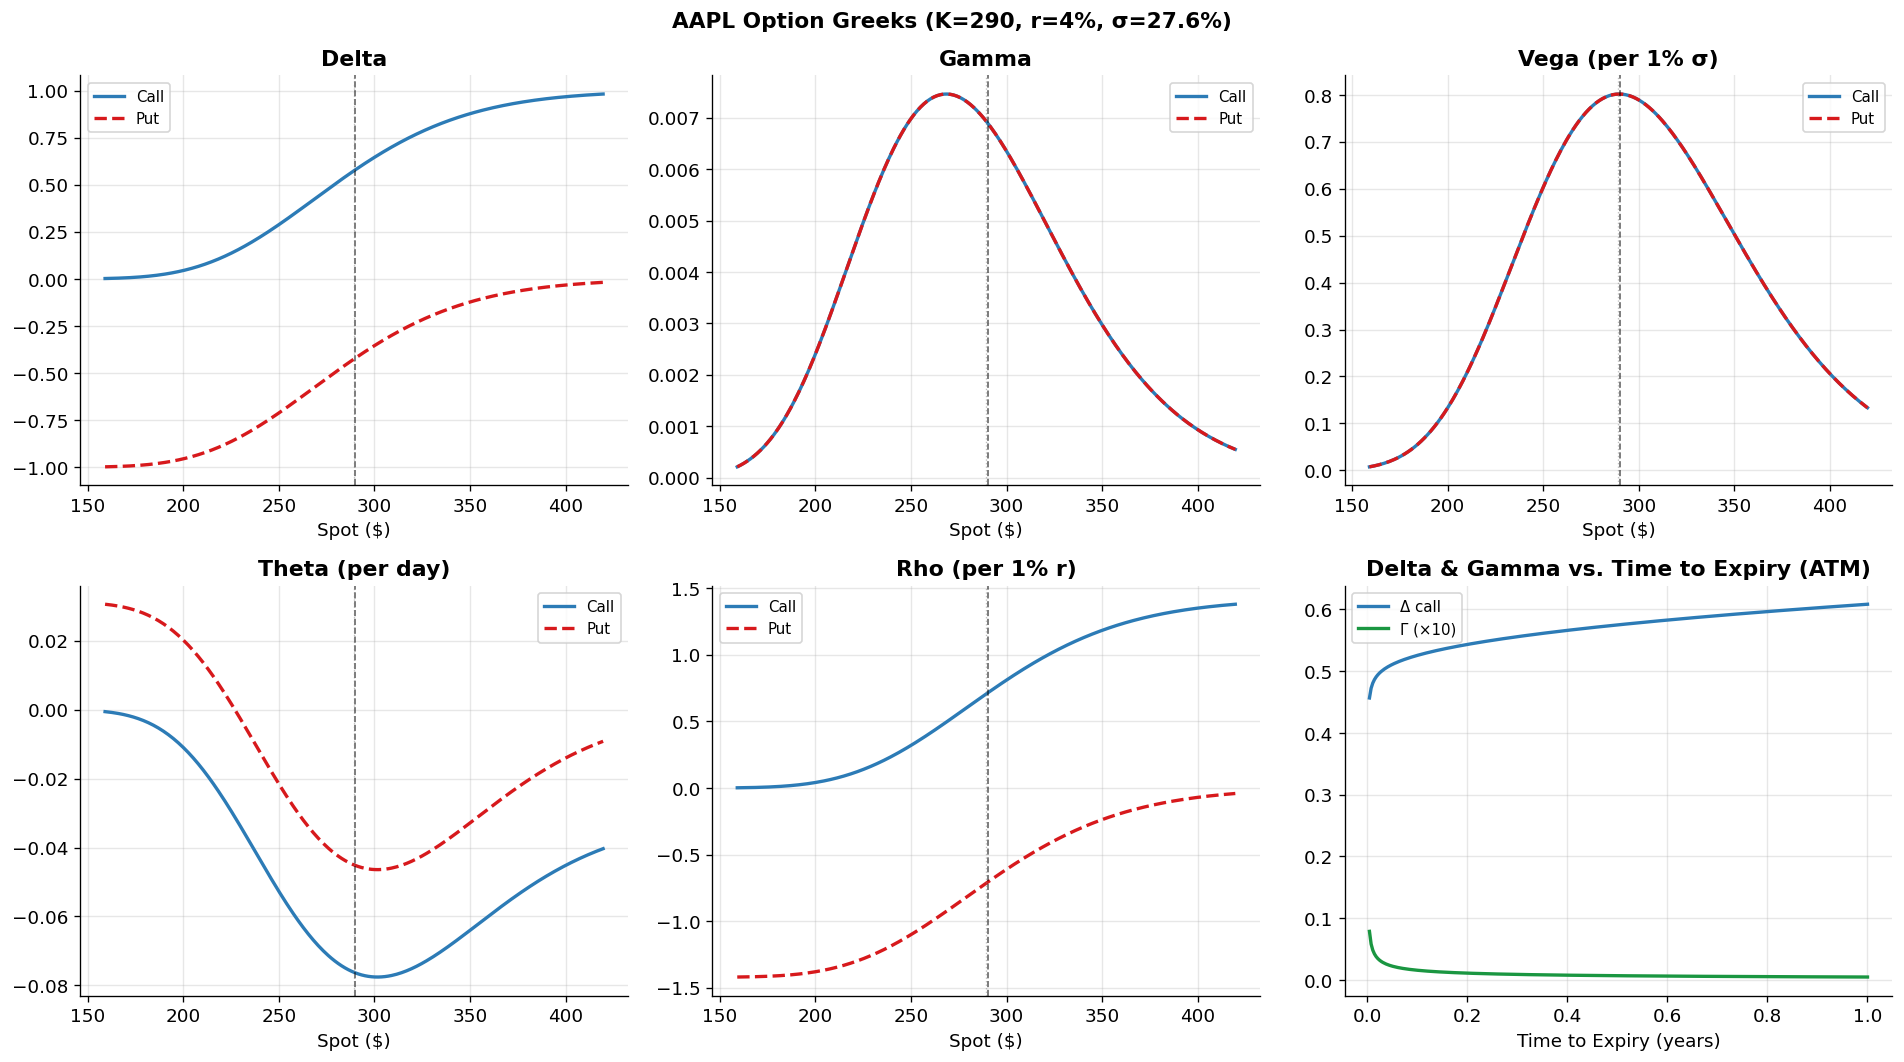

In [7]:
# ── Greeks vs. Spot Price plots ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

S_range = np.linspace(S0 * 0.55, S0 * 1.45, 300)

greek_specs = [
    ('Delta',  lambda S: bs_delta(S, K_atm, T_ex, r, sigma, 'call'),
               lambda S: bs_delta(S, K_atm, T_ex, r, sigma, 'put')),
    ('Gamma',  lambda S: bs_gamma(S, K_atm, T_ex, r, sigma),
               lambda S: bs_gamma(S, K_atm, T_ex, r, sigma)),
    ('Vega (per 1% σ)',
               lambda S: bs_vega(S, K_atm, T_ex, r, sigma),
               lambda S: bs_vega(S, K_atm, T_ex, r, sigma)),
    ('Theta (per day)',
               lambda S: bs_theta(S, K_atm, T_ex, r, sigma, 'call'),
               lambda S: bs_theta(S, K_atm, T_ex, r, sigma, 'put')),
    ('Rho (per 1% r)',
               lambda S: bs_rho(S, K_atm, T_ex, r, sigma, 'call'),
               lambda S: bs_rho(S, K_atm, T_ex, r, sigma, 'put')),
]

for ax, (name, call_fn, put_fn) in zip(axes[:5], greek_specs):
    ax.plot(S_range, call_fn(S_range), color=BLUE, lw=2, label='Call')
    ax.plot(S_range, put_fn (S_range), color=RED,  lw=2, label='Put', ls='--')
    ax.axvline(K_atm, color='black', lw=1.0, ls='--', alpha=0.6)
    ax.axvline(S0,    color='grey',  lw=0.8, ls=':',  alpha=0.5)
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Spot ($)')
    ax.legend(fontsize=9)

# Greeks vs. Time to expiry (ATM option)
T_range = np.linspace(1/252, 1.0, 300)
axes[5].plot(T_range, bs_delta(S0, K_atm, T_range, r, sigma, 'call'), color=BLUE, lw=2, label='Δ call')
axes[5].plot(T_range, bs_gamma(S0, K_atm, T_range, r, sigma),         color=GREEN, lw=2, label='Γ (×10)')
axes[5].set_title('Delta & Gamma vs. Time to Expiry (ATM)', fontweight='bold')
axes[5].set_xlabel('Time to Expiry (years)')
axes[5].legend(fontsize=9)

plt.suptitle(f'{TICKER} Option Greeks (K={K_atm}, r={r:.0%}, σ={sigma:.1%})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 3 — Put–Call Parity and No-Arbitrage Bounds

<div style="background:#fff8e1; border-left:5px solid #FDAE61; padding:14px 18px; border-radius:5px;">

**Put–Call Parity** (adapted from *Financial Analytics* Options Arbitrage material):

$$C - P = S - K e^{-rT}$$

Any violation is an arbitrage. We verify numerically across a range of strikes and spot prices, and show the no-arbitrage bounds:

$$\max(S - K e^{-rT}, 0) \leq C \leq S, \qquad \max(K e^{-rT} - S, 0) \leq P \leq K e^{-rT}$$

</div>

In [8]:
# ── Put–Call Parity verification (from Options Arbitrage FA material) ────────
strikes = np.arange(S0 * 0.80, S0 * 1.20, S0 * 0.02)

calls = bs_call(S0, strikes, T_ex, r, sigma)
puts  = bs_put (S0, strikes, T_ex, r, sigma)

parity_lhs  = calls - puts
parity_rhs  = S0 - strikes * np.exp(-r * T_ex)
parity_diff = parity_lhs - parity_rhs

print('Put–Call Parity check (C - P vs. S - K·e^{-rT}):')  
pcp_df = pd.DataFrame({'Strike K': strikes,
                        'Call':     calls,
                        'Put':      puts,
                        'C − P':    parity_lhs,
                        'S − Ke^{-rT}': parity_rhs,
                        'Diff (≈0)': parity_diff}).round(8)
print(pcp_df.to_string(index=False))

max_error = np.max(np.abs(parity_diff))
print(f'\nMax parity violation: {max_error:.2e} (numerical precision — no arbitrage)')

Put–Call Parity check (C - P vs. S - K·e^{-rT}):
  Strike K      Call       Put      C − P  S − Ke^{-rT}  Diff (≈0)
231.487988 65.011569  2.555802  62.455766     62.455766       -0.0
237.275188 60.130626  3.347465  56.783161     56.783161       -0.0
243.062388 55.417442  4.306887  51.110555     51.110555        0.0
248.849587 50.888538  5.450588  45.437950     45.437950        0.0
254.636787 46.558678  6.793334  39.765344     39.765344        0.0
260.423987 42.440458  8.347719  34.092739     34.092739        0.0
266.211187 38.543982 10.123848  28.420133     28.420133       -0.0
271.998386 34.876654 12.129125  22.747528     22.747528       -0.0
277.785586 31.443086 14.368163  17.074923     17.074923        0.0
283.572786 28.245108 16.842791  11.402317     11.402317        0.0
289.359985 25.281876 19.552164   5.729712      5.729712       -0.0
295.147185 22.550055 22.492949   0.057106      0.057106        0.0
300.934385 20.044072 25.659571  -5.615499     -5.615499       -0.0
306.721584 17

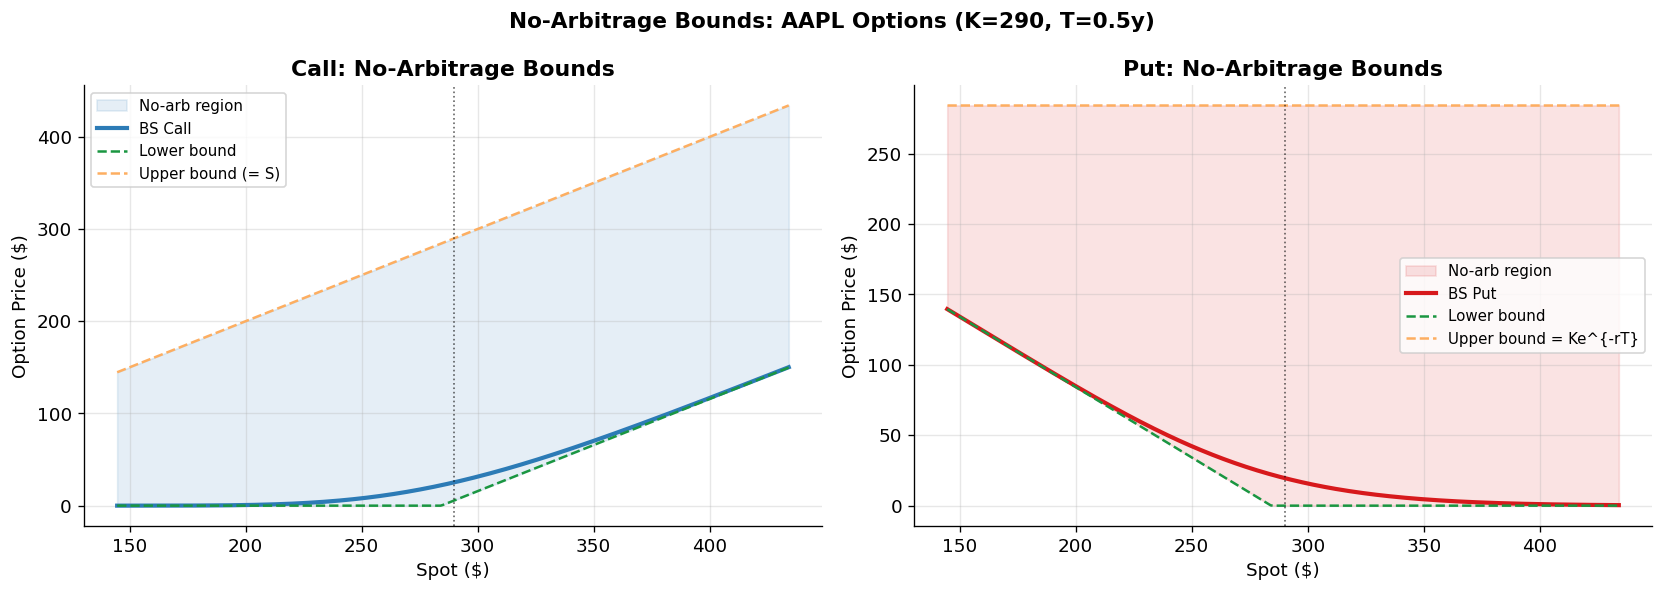

In [9]:
# ── No-arbitrage bounds visualisation ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

S_plot = np.linspace(S0 * 0.5, S0 * 1.5, 300)
Ke_rT  = K_atm * np.exp(-r * T_ex)

# Call bounds
c_prices = bs_call(S_plot, K_atm, T_ex, r, sigma)
c_lower  = np.maximum(S_plot - Ke_rT, 0)

axes[0].fill_between(S_plot, c_lower, S_plot, alpha=0.12, color=BLUE, label='No-arb region')
axes[0].plot(S_plot, c_prices, color=BLUE, lw=2.5, label='BS Call')
axes[0].plot(S_plot, c_lower,  color=GREEN, lw=1.5, ls='--', label='Lower bound')
axes[0].plot(S_plot, S_plot,   color=GOLD,  lw=1.5, ls='--', label='Upper bound (= S)')
axes[0].axvline(K_atm, color='black', lw=1, ls=':', alpha=0.6)
axes[0].set_title('Call: No-Arbitrage Bounds', fontweight='bold')
axes[0].set_xlabel('Spot ($)'); axes[0].set_ylabel('Option Price ($)')
axes[0].legend(fontsize=9)

# Put bounds
p_prices = bs_put(S_plot, K_atm, T_ex, r, sigma)
p_lower  = np.maximum(Ke_rT - S_plot, 0)
p_upper  = np.full_like(S_plot, Ke_rT)

axes[1].fill_between(S_plot, p_lower, p_upper, alpha=0.12, color=RED, label='No-arb region')
axes[1].plot(S_plot, p_prices, color=RED,   lw=2.5, label='BS Put')
axes[1].plot(S_plot, p_lower,  color=GREEN, lw=1.5, ls='--', label='Lower bound')
axes[1].plot(S_plot, p_upper,  color=GOLD,  lw=1.5, ls='--', label=f'Upper bound = Ke^{{-rT}}')
axes[1].axvline(K_atm, color='black', lw=1, ls=':', alpha=0.6)
axes[1].set_title('Put: No-Arbitrage Bounds', fontweight='bold')
axes[1].set_xlabel('Spot ($)'); axes[1].set_ylabel('Option Price ($)')
axes[1].legend(fontsize=9)

plt.suptitle(f'No-Arbitrage Bounds: {TICKER} Options (K={K_atm}, T={T_ex:.1f}y)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 4 — CRR Binomial Tree Pricing

<div style="background:#f3eaff; border-left:5px solid #762A83; padding:14px 18px; border-radius:5px;">

The Cox-Ross-Rubinstein (CRR) binomial model discretises the stock process with:

$$u = e^{\sigma\sqrt{\Delta t}}, \quad d = 1/u, \quad p = \frac{e^{r\Delta t} - d}{u - d}$$

As $N \to \infty$, the binomial price converges to the Black–Scholes price.  
This gives a powerful sanity check and handles American options (early exercise) naturally.

</div>

CRR Convergence to Black–Scholes:
 N steps  CRR Call  BS Price     Error
       2 22.573752 24.968462 -2.394710
       5 26.076917 24.968462  1.108455
      10 24.491732 24.968462 -0.476730
      20 24.743996 24.968462 -0.224466
      50 24.890480 24.968462 -0.077982
     100 24.936047 24.968462 -0.032415
     200 24.956721 24.968462 -0.011741
     500 24.967029 24.968462 -0.001433


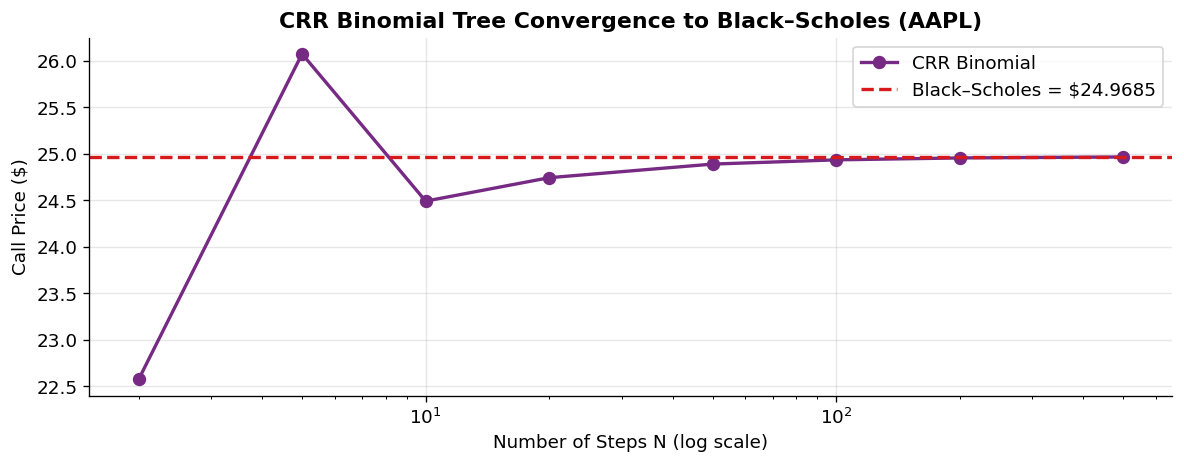


At N=500: CRR = $24.967029, BS = $24.968462, error = $0.001433


In [10]:
# ── CRR Binomial Tree pricer ──────────────────────────────────────────────────

def crr_price(S, K, T, r, sigma, N, option='call', style='european'):
    """
    CRR binomial tree option pricer.
    style: 'european' or 'american'
    """
    dt   = T / N
    u    = np.exp(sigma * np.sqrt(dt))
    d    = 1.0 / u
    p    = (np.exp(r * dt) - d) / (u - d)
    disc = np.exp(-r * dt)

    # Terminal stock prices
    j       = np.arange(N + 1)
    ST      = S * u**j * d**(N - j)

    # Terminal payoffs
    if option == 'call':
        V = np.maximum(ST - K, 0)
    else:
        V = np.maximum(K - ST, 0)

    # Backward induction
    for i in range(N - 1, -1, -1):
        V = disc * (p * V[1:] + (1 - p) * V[:-1])
        if style == 'american':
            S_i = S * u**np.arange(i + 1) * d**(i - np.arange(i + 1))
            if option == 'call':
                V = np.maximum(V, S_i - K)
            else:
                V = np.maximum(V, K - S_i)
    return V[0]

# ── Convergence: binomial vs. BS ─────────────────────────────────────────────
Ns       = [2, 5, 10, 20, 50, 100, 200, 500]
crr_calls = [crr_price(S0, K_atm, T_ex, r, sigma, N, 'call') for N in Ns]
bs_ref    = bs_call(S0, K_atm, T_ex, r, sigma)

conv_df = pd.DataFrame({'N steps': Ns,
                         'CRR Call': crr_calls,
                         'BS Price': bs_ref,
                         'Error':    [c - bs_ref for c in crr_calls]}).round(6)
print('CRR Convergence to Black–Scholes:')
print(conv_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(Ns, crr_calls, 'o-', color=PURPLE, lw=2, ms=7, label='CRR Binomial')
ax.axhline(bs_ref, color=RED, lw=2, ls='--', label=f'Black–Scholes = ${bs_ref:.4f}')
ax.set_xscale('log')
ax.set_xlabel('Number of Steps N (log scale)')
ax.set_ylabel('Call Price ($)')
ax.set_title(f'CRR Binomial Tree Convergence to Black–Scholes ({TICKER})',
             fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'\nAt N=500: CRR = ${crr_calls[-1]:.6f}, BS = ${bs_ref:.6f}, error = ${abs(crr_calls[-1]-bs_ref):.6f}')

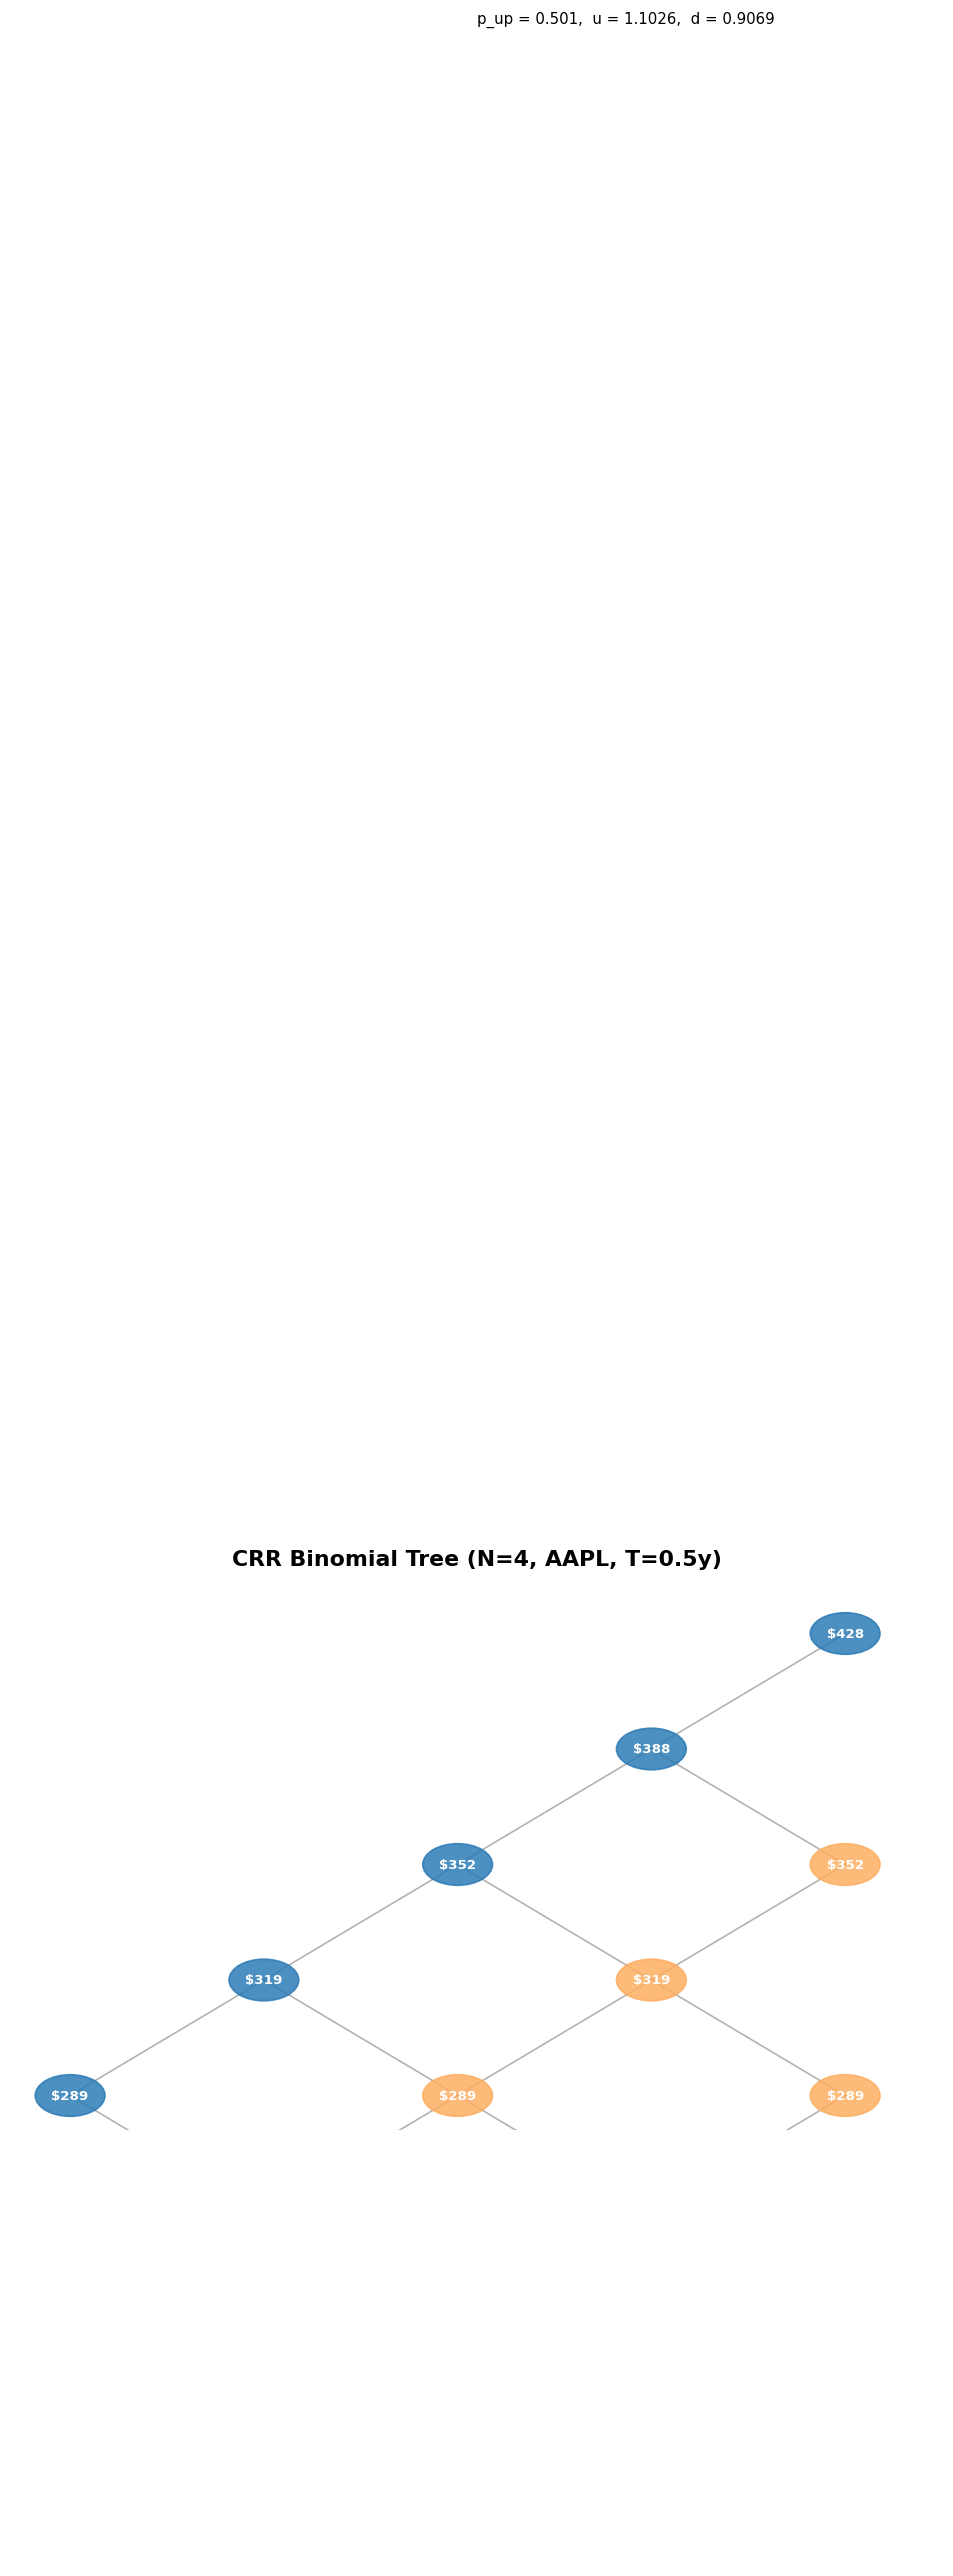

In [11]:
# ── Visualise a small binomial tree (N=4) ────────────────────────────────────
N_viz = 4
dt_v  = T_ex / N_viz
u_v   = np.exp(sigma * np.sqrt(dt_v))
d_v   = 1.0 / u_v
p_v   = (np.exp(r * dt_v) - d_v) / (u_v - d_v)

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(-0.3, N_viz + 0.5)
ax.set_ylim(-0.3, N_viz + 0.5)
ax.axis('off')
ax.set_title(f'CRR Binomial Tree (N={N_viz}, {TICKER}, T={T_ex:.1f}y)', fontweight='bold')

node_prices = {}
for i in range(N_viz + 1):
    for j in range(i + 1):
        S_node = S0 * u_v**(i - j) * d_v**j
        x, y   = i, i - 2 * j
        node_prices[(i, j)] = S_node
        circle = plt.Circle((x, y), 0.18, color=BLUE if j == 0 else RED if j == i else GOLD,
                             alpha=0.85, zorder=3)
        ax.add_patch(circle)
        ax.text(x, y, f'${S_node:.0f}', ha='center', va='center',
                fontsize=8, fontweight='bold', color='white', zorder=4)

# Draw branches
for i in range(N_viz):
    for j in range(i + 1):
        x, y = i, i - 2 * j
        ax.plot([x, i+1], [y, y + 1], color='grey', lw=1, alpha=0.6)
        ax.plot([x, i+1], [y, y - 1], color='grey', lw=1, alpha=0.6)

ax.text(0.5, N_viz * 0.95, f'p_up = {p_v:.3f},  u = {u_v:.4f},  d = {d_v:.4f}',
        transform=ax.transAxes, fontsize=9, color='black')
plt.tight_layout()
plt.show()

---
## Part 5 — Delta-Hedging Simulation on Real AAPL Price Path

<div style="background:#fdecea; border-left:5px solid #D7191C; padding:14px 18px; border-radius:5px;">

**Delta-hedging**: The writer of one ATM call continuously holds Δ shares of stock so that small moves in S are offset. In theory (continuous rebalancing, constant σ), the hedged P&L = 0 regardless of the stock path.

We simulate **daily** rebalancing along the **actual AAPL price path** over the last 6 months:

1. Sell one ATM call for its BS price at inception.
2. Each day: buy/sell shares to maintain delta-neutral position.
3. Track: **hedged P&L** (≈ 0) vs. **unhedged P&L** (naked short call).

</div>

In [12]:
# ── Delta-hedging simulation ──────────────────────────────────────────────────
# Use the last 6 months of actual AAPL price data as our underlying path
hedge_prices = prices.iloc[-126:].copy()   # approx 126 trading days ≈ 6 months
N_days       = len(hedge_prices)
T_total      = N_days / 252              # fraction of a year

S_0_hedge    = float(hedge_prices.iloc[0])
K_hedge      = round(S_0_hedge / 5) * 5   # ATM strike at inception

# Realised vol from the PRECEDING year (use first half of sample)
rv_hedge = float(log_returns.iloc[:252].std() * np.sqrt(252))

print(f'Hedge simulation: {N_days} days on actual {TICKER} path')
print(f'S₀ = ${S_0_hedge:.2f}, K = ${K_hedge:.2f}, T = {T_total:.3f}y, σ = {rv_hedge:.1%}')

# Initial call premium received by writer
c0 = bs_call(S_0_hedge, K_hedge, T_total, r, rv_hedge)
print(f'Call premium received: ${c0:.4f}')

cash         = c0          # cash account (starts with received premium)
shares_held  = 0.0

hedged_pnl   = [0.0]
unhedged_pnl = [0.0]
delta_path   = []

for i in range(N_days):
    S_i    = float(hedge_prices.iloc[i])
    T_rem  = max((N_days - i - 1) / 252, 1/252)   # remaining time

    # Current delta of SHORT call = -Δ
    delta_i = bs_delta(S_i, K_hedge, T_rem, r, rv_hedge, 'call')
    delta_path.append(delta_i)

    # Rebalance: target delta-neutral (short call Δ, hold Δ shares)
    trade       = delta_i - shares_held
    cash       -= trade * S_i          # pay/receive for shares traded
    shares_held = delta_i

    # Daily P&L: mark-to-market
    c_i        = bs_call(S_i, K_hedge, T_rem, r, rv_hedge)
    pf_hedged  = shares_held * S_i + cash * np.exp(r / 252) - c_i
    hedged_pnl.append(pf_hedged)

    # Unhedged: only the short call MTM
    unhedged_pnl.append(c0 - c_i)

# Final payoff at expiry
S_T   = float(hedge_prices.iloc[-1])
payoff = max(S_T - K_hedge, 0)
final_hedged   = shares_held * S_T + cash * np.exp(r * T_total) - payoff
final_unhedged = c0 - payoff
hedged_pnl[-1]   = final_hedged
unhedged_pnl[-1] = final_unhedged

print(f'\nFinal stock price: ${S_T:.2f}')
print(f'Call payoff at expiry: ${payoff:.4f}')
print(f'Hedged P&L:   ${final_hedged:.4f}')
print(f'Unhedged P&L: ${final_unhedged:.4f}')

Hedge simulation: 126 days on actual AAPL path
S₀ = $273.25, K = $275.00, T = 0.500y, σ = 30.0%
Call premium received: $24.7839

Final stock price: $289.36
Call payoff at expiry: $14.3600
Hedged P&L:   $-1.1220
Unhedged P&L: $10.4239


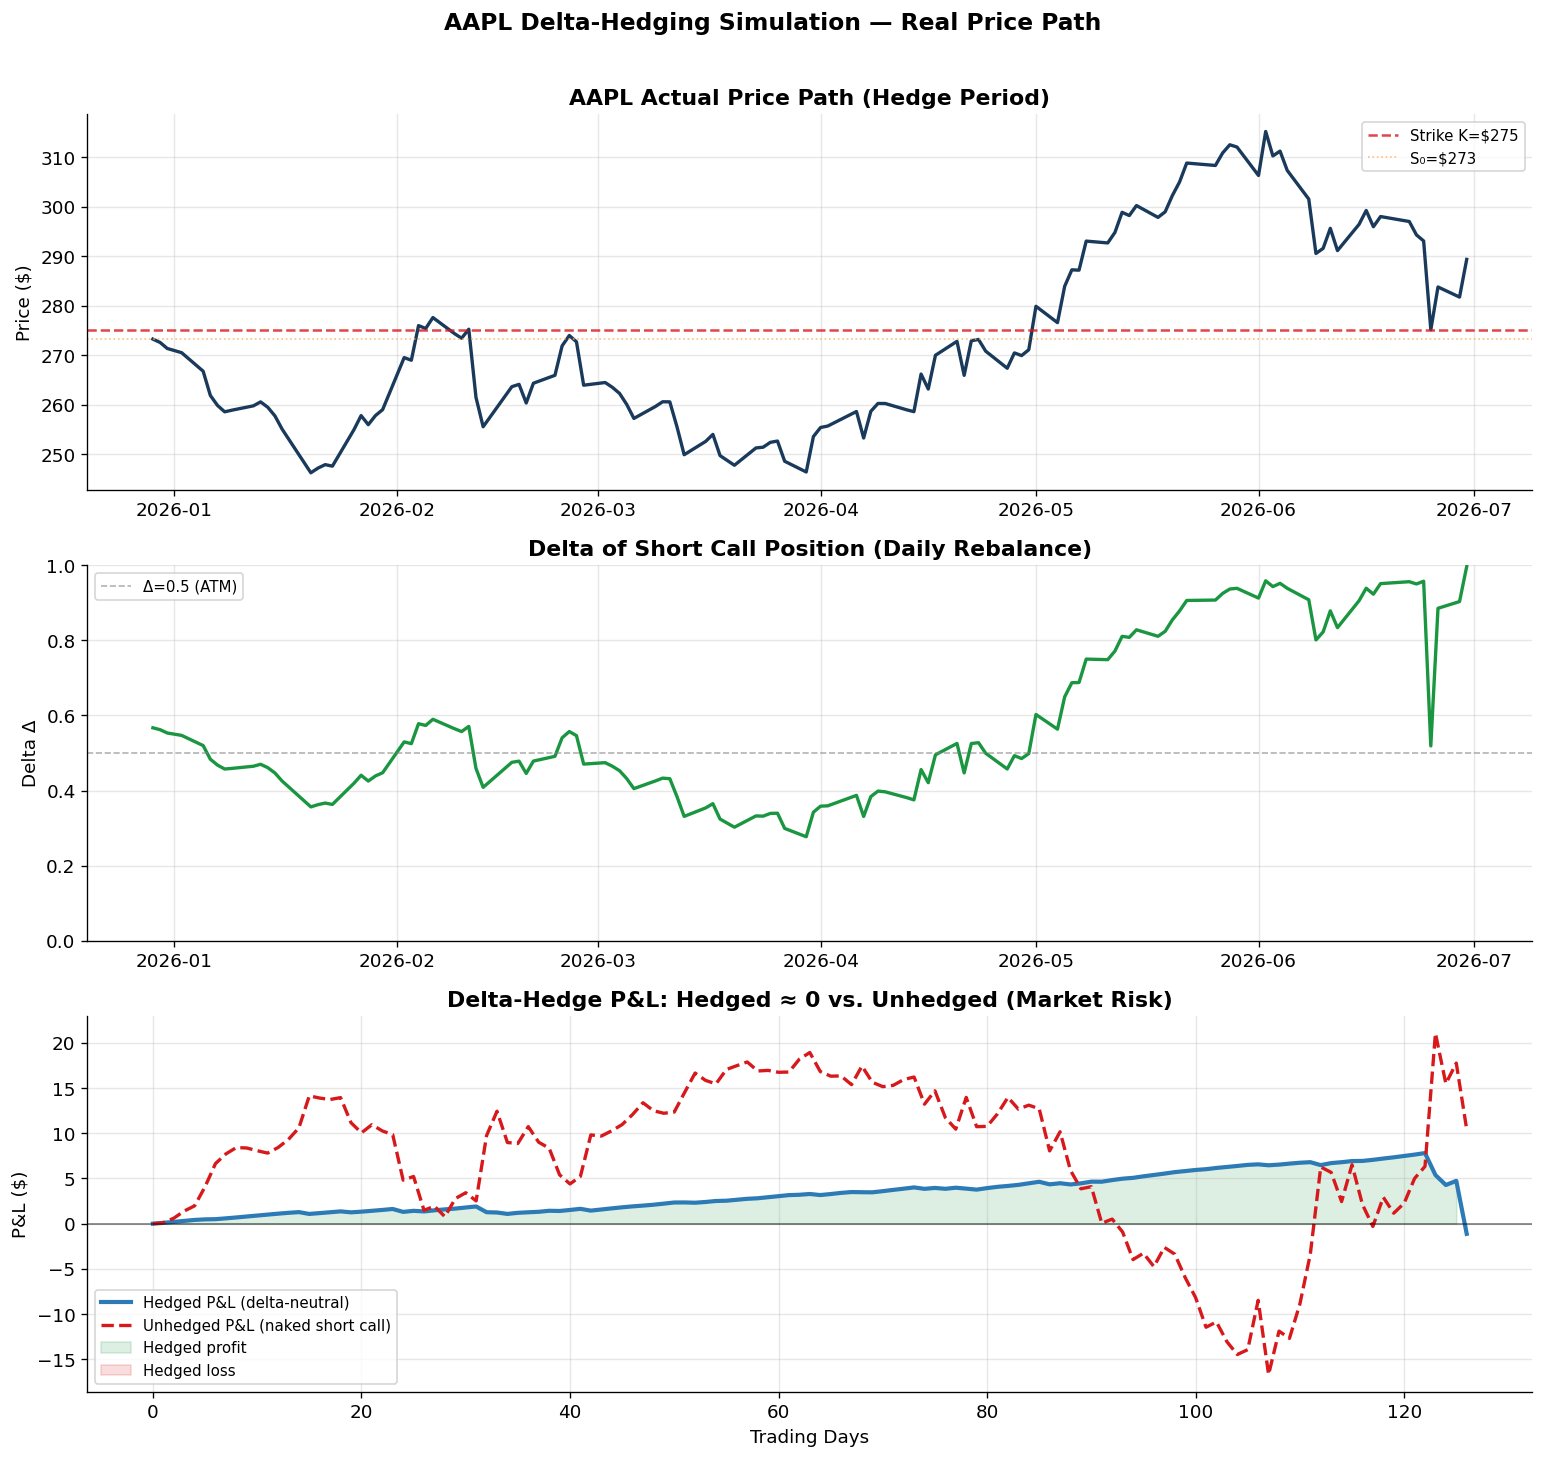


Summary: Hedged P&L std dev = $2.1529, Unhedged std dev = $8.4104


In [13]:
# ── Delta-hedging visualisation ────────────────────────────────────────────────
dates = hedge_prices.index

fig, axes = plt.subplots(3, 1, figsize=(13, 12), sharex=False)

# Panel 1: Stock price path
axes[0].plot(dates, hedge_prices.values, color=NAVY, lw=2)
axes[0].axhline(K_hedge, color=RED, lw=1.5, ls='--', alpha=0.8, label=f'Strike K=${K_hedge}')
axes[0].axhline(S_0_hedge, color=GOLD, lw=1, ls=':', alpha=0.8, label=f'S₀=${S_0_hedge:.0f}')
axes[0].set_title(f'{TICKER} Actual Price Path (Hedge Period)', fontweight='bold')
axes[0].set_ylabel('Price ($)')
axes[0].legend(fontsize=9)

# Panel 2: Delta path
axes[1].plot(dates, delta_path, color=GREEN, lw=2)
axes[1].axhline(0.5, color='grey', lw=1, ls='--', alpha=0.6, label='Δ=0.5 (ATM)')
axes[1].set_title('Delta of Short Call Position (Daily Rebalance)', fontweight='bold')
axes[1].set_ylabel('Delta Δ')
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=9)

# Panel 3: P&L comparison
pnl_dates = list(dates) + [dates[-1]]
axes[2].plot(range(len(hedged_pnl)),   hedged_pnl,   color=BLUE, lw=2.5, label='Hedged P&L (delta-neutral)')
axes[2].plot(range(len(unhedged_pnl)), unhedged_pnl, color=RED,  lw=2,   label='Unhedged P&L (naked short call)', ls='--')
axes[2].axhline(0, color='black', lw=1, alpha=0.5)
axes[2].fill_between(range(len(hedged_pnl)), hedged_pnl, 0,
                     where=[p > 0 for p in hedged_pnl], alpha=0.15, color=GREEN, label='Hedged profit')
axes[2].fill_between(range(len(hedged_pnl)), hedged_pnl, 0,
                     where=[p < 0 for p in hedged_pnl], alpha=0.15, color=RED, label='Hedged loss')
axes[2].set_title('Delta-Hedge P&L: Hedged ≈ 0 vs. Unhedged (Market Risk)',
                  fontweight='bold')
axes[2].set_ylabel('P&L ($)')
axes[2].set_xlabel('Trading Days')
axes[2].legend(fontsize=9)

plt.suptitle(f'{TICKER} Delta-Hedging Simulation — Real Price Path',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'\nSummary: Hedged P&L std dev = ${np.std(hedged_pnl):.4f}, '
      f'Unhedged std dev = ${np.std(unhedged_pnl):.4f}')

---
## Part 6 — Implied Volatility and the Volatility Smile

<div style="background:#eafaf1; border-left:5px solid #1A9641; padding:14px 18px; border-radius:5px;">

**Implied volatility (IV)** is the σ that makes the BS formula equal the observed market price.  
We extract IV numerically using **Brent's method** (fast, bracketed root-finding).

In practice, IV is **not constant across strikes** — lower strikes often have higher IV ("volatility skew" or "smile"), reflecting crash risk and supply/demand imbalances.

</div>

Round-trip: input σ = 0.276374, recovered IV = 0.276374, error = 4.25e-14


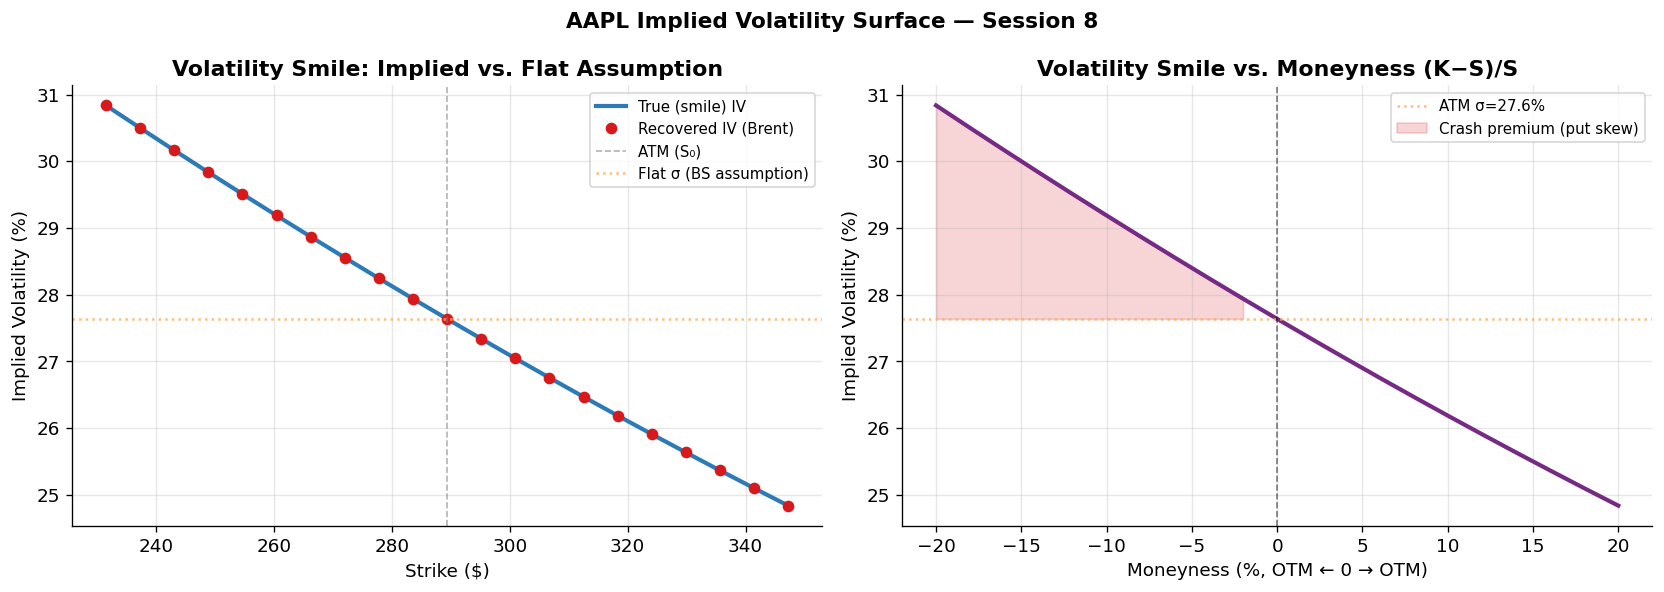


Implied vol at ATM: 27.64%
Implied vol at 80% moneyness: 30.84%
Implied vol at 120% moneyness: 24.84%


In [14]:
# ── Implied volatility solver (Brent) ────────────────────────────────────────

def implied_vol(market_price, S, K, T, r, option='call', tol=1e-8):
    """
    Solve for implied volatility using Brent's method.
    Returns np.nan if the price is outside the no-arbitrage bounds.
    """
    if option == 'call':
        intrinsic = max(S - K * np.exp(-r * T), 0)
        if market_price < intrinsic or market_price >= S:
            return np.nan
        f = lambda sigma: bs_call(S, K, T, r, sigma) - market_price
    else:
        intrinsic = max(K * np.exp(-r * T) - S, 0)
        if market_price < intrinsic or market_price >= K * np.exp(-r * T):
            return np.nan
        f = lambda sigma: bs_put(S, K, T, r, sigma) - market_price

    try:
        return brentq(f, 1e-6, 10.0, xtol=tol)
    except ValueError:
        return np.nan

# ── Verify: round-trip check ──────────────────────────────────────────────────
test_price = call_price   # use BS price computed earlier
iv_back    = implied_vol(test_price, S0, K_atm, T_ex, r, 'call')
print(f'Round-trip: input σ = {sigma:.6f}, recovered IV = {iv_back:.6f}, error = {abs(iv_back - sigma):.2e}')

# ── Synthetic volatility smile ────────────────────────────────────────────────
# Simulate market prices with a smile embedded (higher IV for lower strikes)
smile_strikes = np.linspace(S0 * 0.80, S0 * 1.20, 21)

def smile_vol(K, S, atm_vol, skew=-0.15, smile=0.05):
    """Simple parametric smile: σ = atm_vol + skew*(K-S)/S + smile*((K-S)/S)^2"""
    x = (K - S) / S
    return atm_vol + skew * x + smile * x**2

true_ivs   = smile_vol(smile_strikes, S0, sigma)
mkt_calls  = bs_call(S0, smile_strikes, T_ex, r, true_ivs)  # prices with smile

# Recover IVs from these prices using flat BS (assuming σ = const)
recovered_ivs = np.array([implied_vol(p, S0, K, T_ex, r, 'call') for p, K in zip(mkt_calls, smile_strikes)])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(smile_strikes, true_ivs * 100,      color=BLUE, lw=2.5, label='True (smile) IV')
axes[0].plot(smile_strikes, recovered_ivs * 100,  'o', color=RED, ms=6, label='Recovered IV (Brent)')
axes[0].axvline(S0, color='grey', lw=1, ls='--', alpha=0.6, label='ATM (S₀)')
axes[0].axhline(sigma * 100, color=GOLD, lw=1.5, ls=':', alpha=0.8, label='Flat σ (BS assumption)')
axes[0].set_title('Volatility Smile: Implied vs. Flat Assumption', fontweight='bold')
axes[0].set_xlabel('Strike ($)')
axes[0].set_ylabel('Implied Volatility (%)')
axes[0].legend(fontsize=9)

# Moneyness view
moneyness = (smile_strikes - S0) / S0 * 100
axes[1].plot(moneyness, true_ivs * 100, color=PURPLE, lw=2.5)
axes[1].axhline(sigma * 100, color=GOLD, lw=1.5, ls=':', alpha=0.8, label=f'ATM σ={sigma:.1%}')
axes[1].axvline(0, color='black', lw=1, ls='--', alpha=0.5)
axes[1].set_title('Volatility Smile vs. Moneyness (K−S)/S', fontweight='bold')
axes[1].set_xlabel('Moneyness (%, OTM ← 0 → OTM)')
axes[1].set_ylabel('Implied Volatility (%)')
axes[1].fill_between(moneyness[moneyness < 0], true_ivs[moneyness < 0] * 100, sigma * 100,
                     alpha=0.18, color=RED, label='Crash premium (put skew)')
axes[1].legend(fontsize=9)

plt.suptitle(f'{TICKER} Implied Volatility Surface — Session 8', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nImplied vol at ATM: {recovered_ivs[len(recovered_ivs)//2]:.2%}')
print(f'Implied vol at 80% moneyness: {recovered_ivs[0]:.2%}')
print(f'Implied vol at 120% moneyness: {recovered_ivs[-1]:.2%}')

### Part 6b — Real implied volatility from the live SPY option chain

<div style="background:#eafaf1; border-left:5px solid #1A9641; padding:14px 18px; border-radius:5px;">

The smile above was <em>synthetic</em>. Here we do it for real: we pulled a snapshot of the
<strong>SPY</strong> (S&amp;P 500 ETF) option chain from Yahoo Finance, cached it so the notebook runs
offline, and now invert Black&ndash;Scholes on <em>every traded contract</em> using the same Brent solver.

Two practical filters make the signal clean:

<ul>
<li><strong>Out-of-the-money only</strong> &mdash; OTM puts below spot, OTM calls above. They are pure time value and the most heavily traded, so their prices carry the cleanest vol signal.</li>
<li><strong>Liquid quotes only</strong> &mdash; contracts that actually traded today, in a &plusmn;20% moneyness band.</li>
</ul>

Simplifications (state them to students): we use a single flat risk-free rate and ignore SPY's
~1% dividend yield, so the two or three strikes right at the money can show a small put/call step.
The <em>shape</em> of the skew and its term structure &mdash; the teaching points &mdash; are unaffected.

</div>

In [15]:
# ── Load the cached SPY chain (live-fetch fallback) and invert BS for every contract ──
OPT_CACHE = os.path.join(CACHE_DIR, 'spy_option_chain.csv')
PX_CACHE  = os.path.join(CACHE_DIR, 'spy_prices.csv')

def fetch_spy_chain(path):
    """Live fallback: pull the SPY chain from Yahoo (cookie + crumb) if the cache is gone."""
    from curl_cffi import requests as creq
    from datetime import datetime, timezone
    sess = creq.Session(impersonate='chrome')
    sess.get('https://fc.yahoo.com'); sess.get('https://finance.yahoo.com')
    crumb = sess.get('https://query1.finance.yahoo.com/v1/test/getcrumb').text.strip()
    def chain(date=None):
        p = {'crumb': crumb}
        if date: p['date'] = date
        return sess.get('https://query1.finance.yahoo.com/v7/finance/options/SPY',
                        params=p).json()['optionChain']['result'][0]
    base = chain(); spot = float(base['quote']['regularMarketPrice'])
    asof = datetime.now(timezone.utc).strftime('%Y-%m-%d %H:%M UTC')
    exps = base['expirationDates']; idx = sorted(set([0, 1, 2, 4, 7, 11, 16, len(exps) - 1]))
    rows = []
    for e in [exps[i] for i in idx if i < len(exps)]:
        d = chain(e); exp = datetime.fromtimestamp(e, tz=timezone.utc).strftime('%Y-%m-%d')
        o = d['options'][0]
        for typ, side in [('call', o['calls']), ('put', o['puts'])]:
            for q in side:
                rows.append(dict(expiry=exp, type=typ, strike=q.get('strike'), bid=q.get('bid'),
                                 ask=q.get('ask'), lastPrice=q.get('lastPrice'),
                                 volume=q.get('volume'), openInterest=q.get('openInterest')))
    out = pd.DataFrame(rows); out['spot'] = spot; out['asof'] = asof
    out.to_csv(path, index=False); return out

if os.path.exists(OPT_CACHE):
    chain = pd.read_csv(OPT_CACHE)
    print(f'Loaded SPY chain from cache: {len(chain)} contracts')
else:
    print('Cache missing — fetching a live SPY chain from Yahoo...')
    chain = fetch_spy_chain(OPT_CACHE)

S_spy = float(chain['spot'].iloc[0])
asof  = pd.to_datetime(chain['asof'].iloc[0].split()[0])
chain['tau']       = (pd.to_datetime(chain['expiry']) - asof).dt.days / 365.0   # years to expiry
chain['moneyness'] = chain['strike'] / S_spy

# Keep liquid, out-of-the-money quotes in a sensible band, then invert BS on the last traded price.
otm = chain[(((chain.type == 'call') & (chain.strike >= S_spy)) |
             ((chain.type == 'put')  & (chain.strike <  S_spy)))
            & (chain.volume > 0) & (chain.lastPrice >= 0.05)
            & (chain.moneyness.between(0.80, 1.20)) & (chain.tau > 0.01)].copy()

otm['iv'] = [implied_vol(p, S_spy, K, T, r, option=t)
             for p, K, T, t in zip(otm.lastPrice, otm.strike, otm.tau, otm.type)]
otm = otm.dropna(subset=['iv'])
otm = otm[otm.iv.between(0.03, 1.5)]          # drop nonsense from stale far-OTM prints

print(f'SPY spot ${S_spy:.2f}  as of {asof.date()}  |  usable IV points: {len(otm)}')
print('Expiries used:', ', '.join(sorted(otm.expiry.unique())))

Loaded SPY chain from cache: 2365 contracts


SPY spot $754.15  as of 2026-07-15  |  usable IV points: 508
Expiries used: 2026-07-21, 2026-07-24, 2026-08-21, 2026-10-16, 2028-12-15


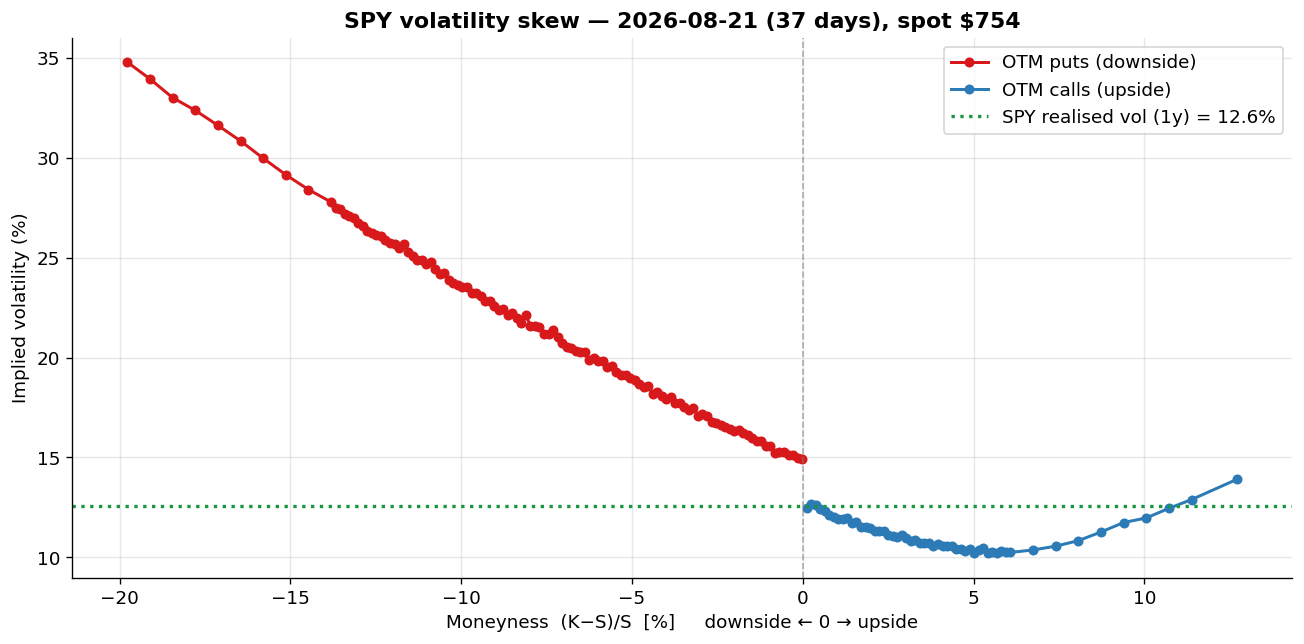

ATM implied vol ≈ 14.9%   |   deep-OTM put IV ≈ 34.8%   |   OTM call IV ≈ 10.2%
Downside crash protection (left) is far dearer than upside (right): the equity "skew".


In [16]:
# ── The volatility skew for the ~1-month expiry ───────────────────────────────
exp_days   = otm.groupby('expiry').tau.first() * 365
target_exp = (exp_days - 30).abs().idxmin()            # listed expiry closest to 30 days
Td         = exp_days[target_exp]
sm         = otm[otm.expiry == target_exp].sort_values('strike')

# SPY realised vol from cached history, for a reference line
if os.path.exists(PX_CACHE):
    spx   = pd.read_csv(PX_CACHE, parse_dates=['Date'])
    rvret = np.log(spx.Close / spx.Close.shift(1)).dropna()
    rv_1y = rvret.iloc[-252:].std() * np.sqrt(252)
else:
    rv_1y = np.nan

fig, ax = plt.subplots(figsize=(11, 5.5))
puts, calls = sm[sm.type == 'put'], sm[sm.type == 'call']
ax.plot((puts.moneyness - 1) * 100,  puts.iv * 100,  'o-', color=RED,  ms=5, lw=1.8, label='OTM puts (downside)')
ax.plot((calls.moneyness - 1) * 100, calls.iv * 100, 'o-', color=BLUE, ms=5, lw=1.8, label='OTM calls (upside)')
ax.axvline(0, color='grey', ls='--', lw=1, alpha=0.6)
if not np.isnan(rv_1y):
    ax.axhline(rv_1y * 100, color=GREEN, ls=':', lw=2, label=f'SPY realised vol (1y) = {rv_1y:.1%}')
ax.set_title(f'SPY volatility skew — {target_exp} ({Td:.0f} days), spot ${S_spy:.0f}', fontweight='bold')
ax.set_xlabel('Moneyness  (K−S)/S  [%]     downside ← 0 → upside')
ax.set_ylabel('Implied volatility (%)')
ax.legend()
plt.tight_layout(); plt.show()

atm_iv = sm.loc[(sm.strike - S_spy).abs().idxmin(), 'iv']
print(f'ATM implied vol ≈ {atm_iv:.1%}   |   deep-OTM put IV ≈ {puts.iv.max():.1%}   |   OTM call IV ≈ {calls.iv.min():.1%}')
print('Downside crash protection (left) is far dearer than upside (right): the equity "skew".')

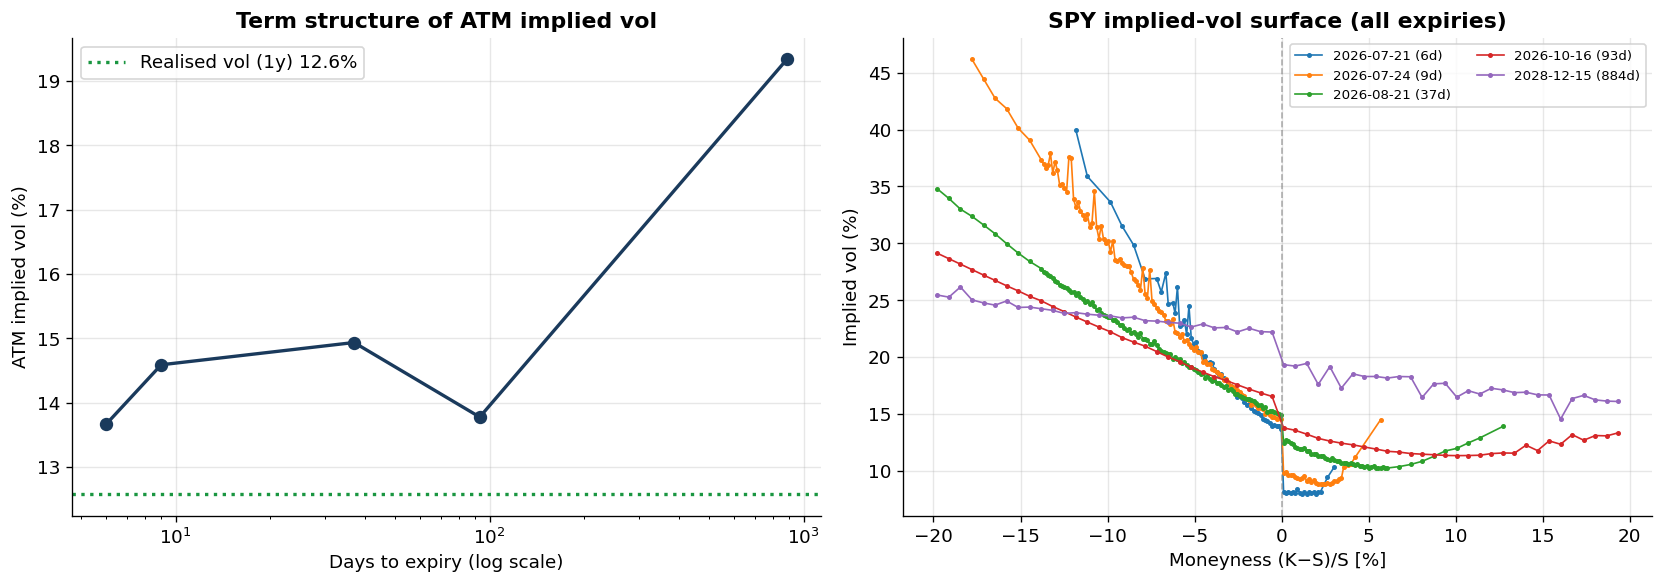

Short-dated smiles are steeper (near-term crash fear); long-dated are flatter and sit higher on average.
Front-month ATM implied 13.7% vs realised 12.6% — the gap is the variance risk premium (insurance sellers earn it on average).


In [17]:
# ── Term structure of ATM implied vol, and the whole IV surface ───────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (left) ATM implied vol vs maturity
atm = (otm.assign(absm=(otm.strike - S_spy).abs())
          .sort_values('absm').groupby('expiry').first().reset_index().sort_values('tau'))
axes[0].plot(atm.tau * 365, atm.iv * 100, 'o-', color=NAVY, lw=2, ms=7)
if not np.isnan(rv_1y):
    axes[0].axhline(rv_1y * 100, color=GREEN, ls=':', lw=2, label=f'Realised vol (1y) {rv_1y:.1%}')
    axes[0].legend()
axes[0].set_xscale('log')
axes[0].set_title('Term structure of ATM implied vol', fontweight='bold')
axes[0].set_xlabel('Days to expiry (log scale)'); axes[0].set_ylabel('ATM implied vol (%)')

# (right) the full surface: IV vs moneyness, one line per expiry
for exp, g in otm.groupby('expiry'):
    g = g.sort_values('moneyness')
    axes[1].plot((g.moneyness - 1) * 100, g.iv * 100, '.-', ms=4, lw=1,
                 label=f'{exp} ({g.tau.iloc[0] * 365:.0f}d)')
axes[1].axvline(0, color='grey', ls='--', lw=1, alpha=0.6)
axes[1].set_title('SPY implied-vol surface (all expiries)', fontweight='bold')
axes[1].set_xlabel('Moneyness (K−S)/S [%]'); axes[1].set_ylabel('Implied vol (%)')
axes[1].legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.show()

print('Short-dated smiles are steeper (near-term crash fear); long-dated are flatter and sit higher on average.')
if not np.isnan(rv_1y):
    print(f'Front-month ATM implied {atm.iloc[0].iv:.1%} vs realised {rv_1y:.1%} '
          f'— the gap is the variance risk premium (insurance sellers earn it on average).')

<div style="background:#eef4fb; border-left:5px solid #2C7BB6; padding:14px 18px; border-radius:5px;">

**What the real chain teaches (that the flat BS model cannot):**

1. **There is no single volatility.** Every strike and expiry implies its own σ. Quoting one number for "SPY vol" is a convenience, not a fact.
2. **The skew is the market pricing crash risk.** Downside puts trade at much higher IV than upside calls — investors pay up for protection, exactly the fat left tail we saw in the return histograms of Session 2.
3. **Implied usually sits above realised.** The gap between front-month ATM implied vol and trailing realised vol is the **variance risk premium** — the compensation option sellers earn for bearing volatility risk.
4. **A flat-σ Black–Scholes price is a starting point, not the truth.** Desks quote in vol and read the smile off the market; the model is the language, not the answer.

*To refresh with live data, delete `notebook_data/spy_option_chain.csv` (and `spy_prices.csv`) and re-run — the cell falls back to a live Yahoo pull.*

</div>

---
## Session 8 Summary

| Concept | Key Formula | Python Tool |
|---------|-------------|-------------|
| Black–Scholes price | $C = S N(d_1) - K e^{-rT} N(d_2)$ | `scipy.stats.norm`, `bs_call()` |
| The Greeks | Δ, Γ, ν, Θ, ρ — closed-form | `bs_delta()`, `bs_gamma()`, ... |
| Put–Call Parity | $C - P = S - K e^{-rT}$ | Numerical check |
| Binomial tree | $u=e^{\sigma\sqrt{\Delta t}}$, $p=(e^{r\Delta t}-d)/(u-d)$ | `crr_price()` |
| Delta hedging | Short call + Δ shares ≈ riskless | Daily rebalance simulation |
| Implied volatility | Invert BS via root-finding | `scipy.optimize.brentq` |
| Volatility smile | IV varies across strikes | Parametric smile model |

<div style="background:#f0f4fa; border-left:5px solid #2C7BB6; padding:14px 18px; border-radius:5px; margin-top:10px;">
<b>Key risk management insight:</b> Options are not a zero-cost insurance policy — they have Greeks. Delta hedging eliminates directional risk but leaves <b>gamma risk</b> (cost of rebalancing when the stock moves) and <b>vega risk</b> (if realised vol differs from implied). The volatility smile reminds us that BS is a framework, not a perfect model.
</div>

**Next session (Session 9):** Portfolio Risk and Optimization I — mean-variance, efficient frontier.

---
*Yuriy Zabolotnyuk &nbsp;·&nbsp; Sprott School of Business &nbsp;·&nbsp; Carleton University*

---
## Your Turn — Hands-On Derivatives Exercise

<div style="background:#fff8e1; border-left:5px solid #FDAE61; padding:14px 18px; border-radius:5px;">

Price and hedge an option on a stock of **your own choice**. Complete all five parts below.

</div>

### Part A — Data & Realised Volatility
1. Choose a liquid stock ticker (not AAPL).
2. Download 2 years of daily close prices (`START='2024-01-01'`, `END='2026-07-01'`).
3. Compute log returns and annualised realised volatility.
4. Report: ticker, current price, realised vol.

### Part B — Black–Scholes Pricing
1. Choose an ATM strike (nearest $5) and T = 3 months (0.25 years), r = 4%.
2. Price the call and put using `bs_call()` / `bs_put()`.
3. Verify put–call parity: confirm `C - P ≈ S - K·e^{-rT}`.

### Part C — Greeks Report
1. Compute all five Greeks (Δ, Γ, ν, Θ, ρ) for your call and put.
2. Plot Delta and Gamma vs. spot price across a ±30% range around current price.
3. Interpret each Greek in one sentence (as a comment in your code).

### Part D — Binomial Tree
1. Price your call using `crr_price()` at N = {10, 50, 100, 200}.
2. Plot the convergence to your BS price.
3. Also price the **American put** (N=200) — is it more expensive than European? Why?

### Part E — Delta-Hedge Simulation
1. Run the delta-hedge simulation on the last 63 trading days (≈ 3 months) of your stock.
2. Plot: (a) stock path, (b) delta path, (c) hedged vs. unhedged P&L.
3. Report the final hedged P&L and unhedged P&L.
4. Reflection (markdown cell): Why does the hedged P&L differ from zero? What risks remain?

In [18]:
# ── Part A: Choose your stock, download data, compute realised vol ─────────────
MY_TICKER = 'MSFT'   # CHANGE THIS to your chosen stock

# YOUR CODE HERE


In [19]:
# ── Part B: BS Pricing and Put–Call Parity check ──────────────────────────────

# YOUR CODE HERE


In [20]:
# ── Part C: Greeks report and plots ──────────────────────────────────────────

# YOUR CODE HERE


In [21]:
# ── Part D: CRR Binomial Tree and convergence plot ────────────────────────────

# YOUR CODE HERE


In [22]:
# ── Part E: Delta-hedge simulation on your stock ──────────────────────────────

# YOUR CODE HERE


### Reflection (Part E)

*[Write your 3–5 sentence reflection here — why does the hedged P&L differ from zero? What residual risks remain after delta hedging?]*